# 🔬 Carbon-24: Phát Hiện Dị Biệt & Dự Đoán Năng Lượng

**Mục tiêu:**
1. Phát hiện cấu trúc dị biệt (anomaly detection)
2. Phân loại nhóm ổn định/kém ổn định
3. Dự đoán energy_per_atom với Machine Learning
4. Trực quan hóa kết quả

**Dataset:** 10,153 cấu trúc Carbon-24

In [9]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.linear_model import Ridge, Lasso
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.covariance import EllipticEnvelope
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from scipy import stats

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print(' Libraries imported successfully!')

 Libraries imported successfully!


##  1. Load Data

In [10]:
# Load preprocessed data
df = pd.read_csv('carbon24_feature_selected/carbon24_feature_selected_standard.csv')

# Load original data for energy_per_atom
df_original = pd.read_csv('carbon24_features/carbon24_project/data/carbon24_features.csv')
df_original['energy_per_atom'] = df_original['energy'] / df_original['num_atoms']

# Merge
df = df.merge(df_original[['row_index', 'energy_per_atom', 'energy']], on='row_index', how='left')

# Load feature info
with open('carbon24_feature_selected/selected_features.json', 'r') as f:
    feature_info = json.load(f)

numeric_features = feature_info['numeric_features']

print(f' Loaded {len(df):,} structures')
print(f'   Features: {len(numeric_features)}')
print(f'\nFirst few rows:')
df.head()

 Loaded 10,153 structures
   Features: 22

First few rows:


,formula,elements,num_atoms,a,b,c,alpha,beta,gamma,angle_deviation,...,split,source_file,material_id,relative_energy,volume_ratio,lattice_asymmetry,bond_complexity,hybridization_diversity,energy_per_atom,energy
0,C,C,-0.896504,-0.528201,0.738689,-0.571066,-1.560016,-1.944031,-2.663564,3.445121,...,train,huggingface,C-130499-1826-36,-0.449890,-0.798002,0.208107,-0.648042,-0.860595,-25.718648,-154.311891
1,C,C,0.220331,-0.511806,0.338174,0.083799,0.050702,-0.756736,-1.818219,0.172052,...,train,huggingface,C-13904-4247-31,-0.598634,-1.078242,0.441402,0.093659,-0.860595,-15.433218,-154.332183
2,C,C,0.220331,-0.596470,0.469011,0.092006,1.543116,0.765592,-0.787466,0.743753,...,train,huggingface,C-92138-4782-35,0.530375,-0.778457,0.589175,-0.500065,0.806312,-15.417816,-154.178157
3,C,C,3.012419,-0.537603,-0.093448,3.347596,0.578627,-0.792132,0.042496,-0.891993,...,train,huggingface,C-192672-505-73,-0.431188,-1.207221,2.398156,-0.091224,-0.860595,-7.715467,-154.309339
4,C,C,-0.896504,1.078734,0.488669,-1.345514,1.167933,2.491922,-0.658669,1.603907,...,train,huggingface,C-193956-5355-22,0.796611,1.275598,-1.325352,-0.653895,-0.860595,-25.690306,-154.141835


In [11]:
# Data info
print(' Dataset Information:')
print(f'   Shape: {df.shape}')
print(f'   Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print(f'\n Energy Statistics:')
print(df[['energy_per_atom', 'relative_energy']].describe())

 Dataset Information:
   Shape: (10153, 33)
   Memory: 5.79 MB

 Energy Statistics:
       energy_per_atom  relative_energy
count     10153.000000     1.015300e+04
mean        -18.825583    -1.063750e-16
std           5.747426     1.000049e+00
min         -25.759379    -2.177508e+00
25%         -25.693428    -6.082049e-01
50%         -19.274748     2.420864e-01
75%         -15.407816     8.320648e-01
max          -6.419519     1.334812e+00


##  2. Phát Hiện Dị Biệt (Anomaly Detection)

Sử dụng nhiều phương pháp để phát hiện cấu trúc bất thường:
- **Isolation Forest** - Phát hiện outliers dựa trên isolation
- **Local Outlier Factor (LOF)** - Phát hiện dựa trên mật độ local
- **One-Class SVM** - Phát hiện dựa trên boundary
- **Elliptic Envelope** - Phát hiện dựa trên Gaussian distribution
- **Statistical Methods** - Z-score và IQR

In [12]:
# Prepare features for anomaly detection
features_for_anomaly = [f for f in numeric_features if f in df.columns]
X_anomaly = df[features_for_anomaly].values

print(f'Features for anomaly detection: {len(features_for_anomaly)}')
print(f'Data shape: {X_anomaly.shape}')

Features for anomaly detection: 22
Data shape: (10153, 22)


In [13]:
# Isolation Forest
print(' Isolation Forest')
print('=' * 60)

iso_forest = IsolationForest(
    contamination=0.05,  # 5% outliers
    random_state=42,
    n_estimators=100
)

df['anomaly_iso_forest'] = iso_forest.fit_predict(X_anomaly)
df['anomaly_score_iso'] = iso_forest.score_samples(X_anomaly)

n_anomalies = (df['anomaly_iso_forest'] == -1).sum()
print(f'Anomalies detected: {n_anomalies:,} ({n_anomalies/len(df)*100:.2f}%)')
print(f'Normal structures: {(df["anomaly_iso_forest"] == 1).sum():,}')
print(f'\nAnomaly score range: [{df["anomaly_score_iso"].min():.4f}, {df["anomaly_score_iso"].max():.4f}]')

 Isolation Forest
Anomalies detected: 508 (5.00%)
Normal structures: 9,645

Anomaly score range: [-0.6640, -0.3944]


In [14]:
# Local Outlier Factor
print(' Local Outlier Factor (LOF)')
print('=' * 60)

lof = LocalOutlierFactor(
    contamination=0.05,
    n_neighbors=20
)

df['anomaly_lof'] = lof.fit_predict(X_anomaly)
df['anomaly_score_lof'] = lof.negative_outlier_factor_

n_anomalies = (df['anomaly_lof'] == -1).sum()
print(f'Anomalies detected: {n_anomalies:,} ({n_anomalies/len(df)*100:.2f}%)')
print(f'Normal structures: {(df["anomaly_lof"] == 1).sum():,}')

 Local Outlier Factor (LOF)
Anomalies detected: 508 (5.00%)
Normal structures: 9,645


In [15]:
# One-Class SVM
print(' One-Class SVM')
print('=' * 60)

ocsvm = OneClassSVM(
    nu=0.05,  # 5% outliers
    kernel='rbf',
    gamma='auto'
)

df['anomaly_ocsvm'] = ocsvm.fit_predict(X_anomaly)

n_anomalies = (df['anomaly_ocsvm'] == -1).sum()
print(f'Anomalies detected: {n_anomalies:,} ({n_anomalies/len(df)*100:.2f}%)')
print(f'Normal structures: {(df["anomaly_ocsvm"] == 1).sum():,}')

 One-Class SVM
Anomalies detected: 506 (4.98%)
Normal structures: 9,647


In [16]:
# Statistical Methods - Z-score
print(' Statistical Methods (Z-score)')
print('=' * 60)

# Calculate Z-scores for energy
z_scores = np.abs(stats.zscore(df['relative_energy']))
df['anomaly_zscore'] = (z_scores > 3).astype(int) * -1 + (z_scores <= 3).astype(int)

n_anomalies = (df['anomaly_zscore'] == -1).sum()
print(f'Anomalies detected (|z| > 3): {n_anomalies:,} ({n_anomalies/len(df)*100:.2f}%)')
print(f'Normal structures: {(df["anomaly_zscore"] == 1).sum():,}')

 Statistical Methods (Z-score)
Anomalies detected (|z| > 3): 0 (0.00%)
Normal structures: 10,153


In [17]:
# Consensus: structures flagged by multiple methods
print(' Consensus Anomaly Detection')
print('=' * 60)

# Count how many methods flagged each structure
anomaly_cols = ['anomaly_iso_forest', 'anomaly_lof', 'anomaly_ocsvm', 'anomaly_zscore']
df['anomaly_count'] = (df[anomaly_cols] == -1).sum(axis=1)

# Consensus: flagged by at least 2 methods
df['is_anomaly'] = (df['anomaly_count'] >= 2).astype(int)

print(f'\nAnomaly Detection Summary:')
for i in range(5):
    count = (df['anomaly_count'] == i).sum()
    print(f'  Flagged by {i} methods: {count:,} ({count/len(df)*100:.2f}%)')

n_consensus = df['is_anomaly'].sum()
print(f'\n Consensus anomalies (≥2 methods): {n_consensus:,} ({n_consensus/len(df)*100:.2f}%)')

 Consensus Anomaly Detection

Anomaly Detection Summary:
  Flagged by 0 methods: 9,016 (88.80%)
  Flagged by 1 methods: 805 (7.93%)
  Flagged by 2 methods: 279 (2.75%)
  Flagged by 3 methods: 53 (0.52%)
  Flagged by 4 methods: 0 (0.00%)

 Consensus anomalies (≥2 methods): 332 (3.27%)


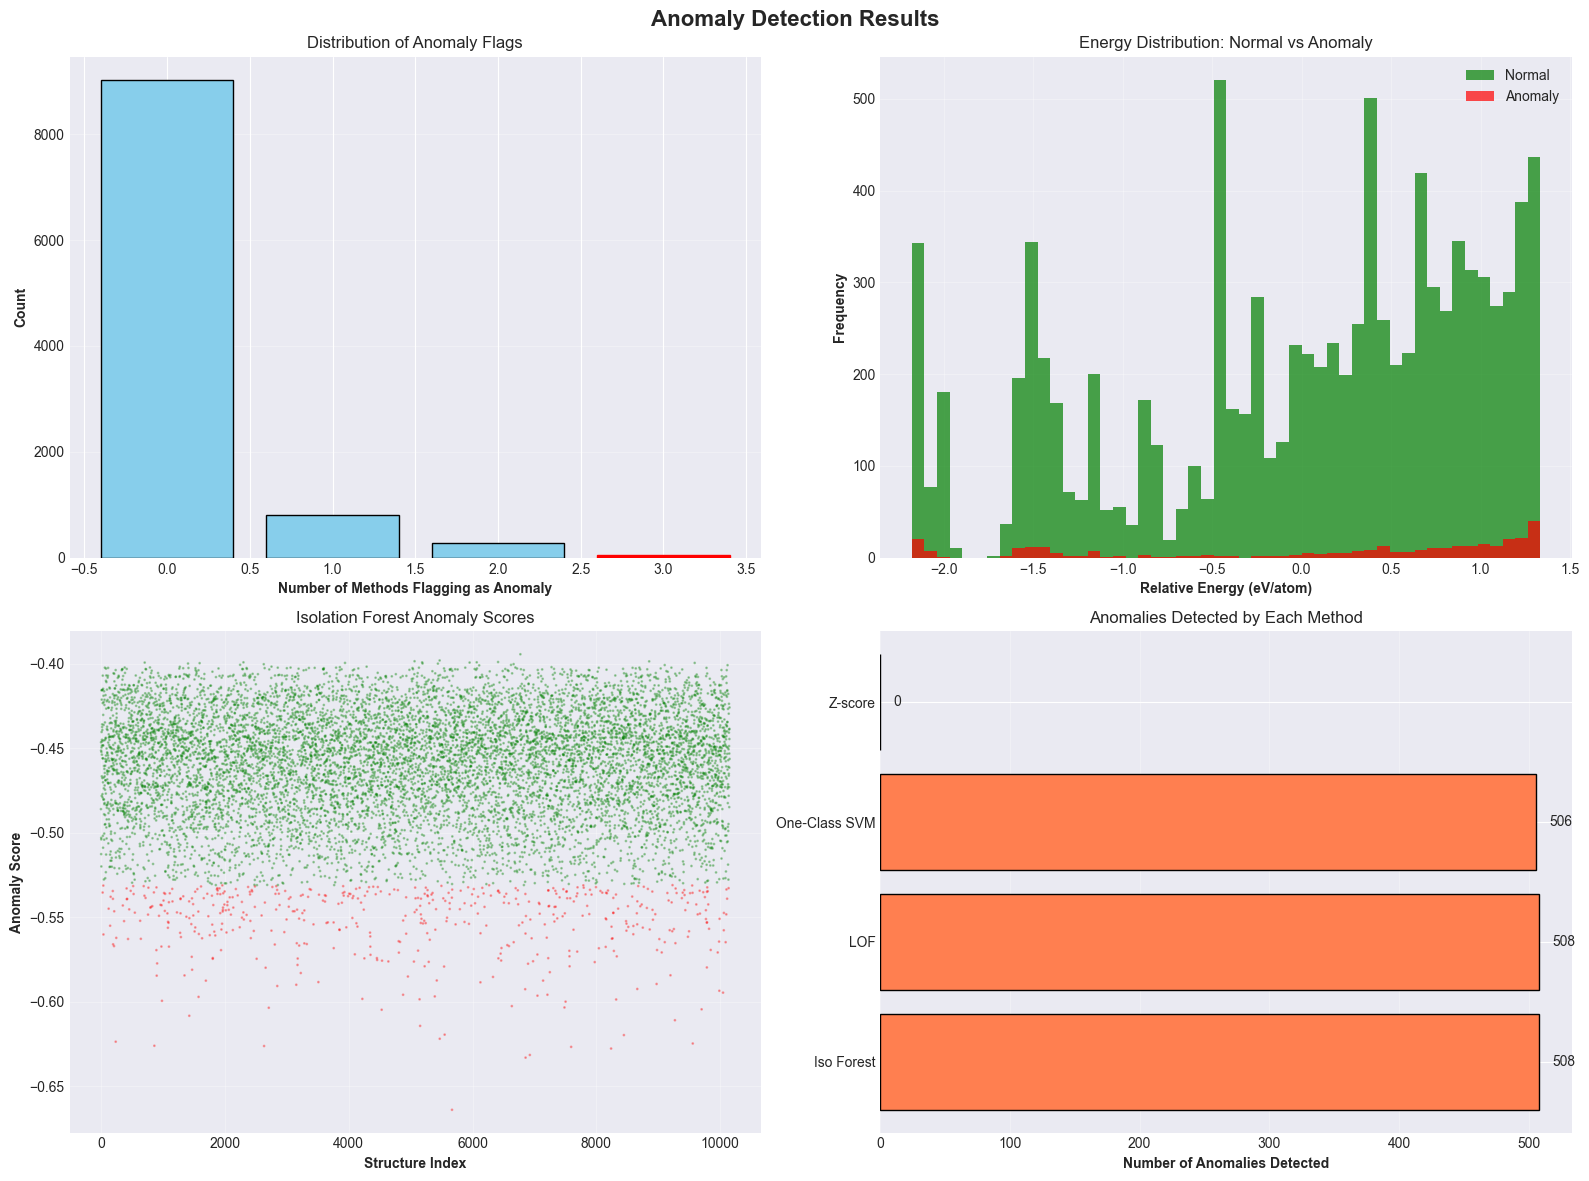

 Visualization complete!


In [18]:
# Visualize anomalies
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Anomaly Detection Results', fontsize=16, fontweight='bold')

# Plot 1: Anomaly counts
ax = axes[0, 0]
anomaly_counts = df['anomaly_count'].value_counts().sort_index()
bars = ax.bar(anomaly_counts.index, anomaly_counts.values, color='skyblue', edgecolor='black')
bars[-1].set_color('red') if len(bars) > 0 else None
ax.set_xlabel('Number of Methods Flagging as Anomaly', fontweight='bold')
ax.set_ylabel('Count', fontweight='bold')
ax.set_title('Distribution of Anomaly Flags')
ax.grid(axis='y', alpha=0.3)

# Plot 2: Energy distribution by anomaly status
ax = axes[0, 1]
normal = df[df['is_anomaly'] == 0]['relative_energy']
anomaly = df[df['is_anomaly'] == 1]['relative_energy']
ax.hist(normal, bins=50, alpha=0.7, label='Normal', color='green')
ax.hist(anomaly, bins=50, alpha=0.7, label='Anomaly', color='red')
ax.set_xlabel('Relative Energy (eV/atom)', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Energy Distribution: Normal vs Anomaly')
ax.legend()
ax.grid(alpha=0.3)

# Plot 3: Isolation Forest scores
ax = axes[1, 0]
colors = ['red' if x == -1 else 'green' for x in df['anomaly_iso_forest']]
ax.scatter(range(len(df)), df['anomaly_score_iso'], c=colors, alpha=0.3, s=1)
ax.set_xlabel('Structure Index', fontweight='bold')
ax.set_ylabel('Anomaly Score', fontweight='bold')
ax.set_title('Isolation Forest Anomaly Scores')
ax.grid(alpha=0.3)

# Plot 4: Method agreement
ax = axes[1, 1]
method_names = ['Iso Forest', 'LOF', 'One-Class SVM', 'Z-score']
method_counts = [(df[col] == -1).sum() for col in anomaly_cols]
bars = ax.barh(method_names, method_counts, color='coral', edgecolor='black')
ax.set_xlabel('Number of Anomalies Detected', fontweight='bold')
ax.set_title('Anomalies Detected by Each Method')
ax.grid(axis='x', alpha=0.3)

for i, (bar, count) in enumerate(zip(bars, method_counts)):
    ax.text(count + 10, i, f'{count:,}', va='center')

plt.tight_layout()
plt.show()

print(' Visualization complete!')

## 3. Phân Loại Stability

Sử dụng clustering để phân loại các cấu trúc theo mức độ ổn định

In [19]:
# Clustering for stability groups
print(' K-means Clustering')
print('=' * 60)

# Prepare features (exclude anomalies and energy)
features_for_clustering = [f for f in numeric_features if f != 'relative_energy' and f in df.columns]
X_cluster = df[features_for_clustering].values

# K-means with k=3
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, max_iter=300, random_state=42)
df['cluster'] = kmeans.fit_predict(X_cluster)

print(f' Clustering completed with k={optimal_k}')
print(f'\nCluster distribution:')
for i in range(optimal_k):
    count = (df['cluster'] == i).sum()
    print(f'  Cluster {i}: {count:,} ({count/len(df)*100:.1f}%)')

 K-means Clustering
 Clustering completed with k=3

Cluster distribution:
  Cluster 0: 3,409 (33.6%)
  Cluster 1: 2,229 (22.0%)
  Cluster 2: 4,515 (44.5%)


In [20]:
# Analyze stability by cluster
print('\n Stability Analysis by Cluster')
print('=' * 60)

stability_stats = df.groupby('cluster')['relative_energy'].agg([
    'count', 'mean', 'std', 'min', 'max', 'median'
]).round(4)

print(stability_stats)

# Classify clusters
print('\n Stability Classification:')
for i in range(optimal_k):
    mean_energy = stability_stats.loc[i, 'mean']
    
    if mean_energy < 0.15:
        stability = " Highly Stable"
    elif mean_energy < 0.30:
        stability = " Moderately Stable"
    else:
        stability = " Less Stable"
    
    count = stability_stats.loc[i, 'count']
    print(f'  Cluster {i}: {stability}')
    print(f'    - Structures: {int(count):,}')
    print(f'    - Mean energy: {mean_energy:.4f} eV/atom')
    print()


 Stability Analysis by Cluster
         count    mean     std     min     max  median
cluster                                               
0         3409 -0.4725  1.0173 -2.1775  1.3348 -0.4371
1         2229 -0.3771  1.1525 -1.7323  1.3348 -1.1366
2         4515  0.5429  0.5278 -1.4196  1.3348  0.6060

 Stability Classification:
  Cluster 0:  Highly Stable
    - Structures: 3,409
    - Mean energy: -0.4725 eV/atom

  Cluster 1:  Highly Stable
    - Structures: 2,229
    - Mean energy: -0.3771 eV/atom

  Cluster 2:  Less Stable
    - Structures: 4,515
    - Mean energy: 0.5429 eV/atom



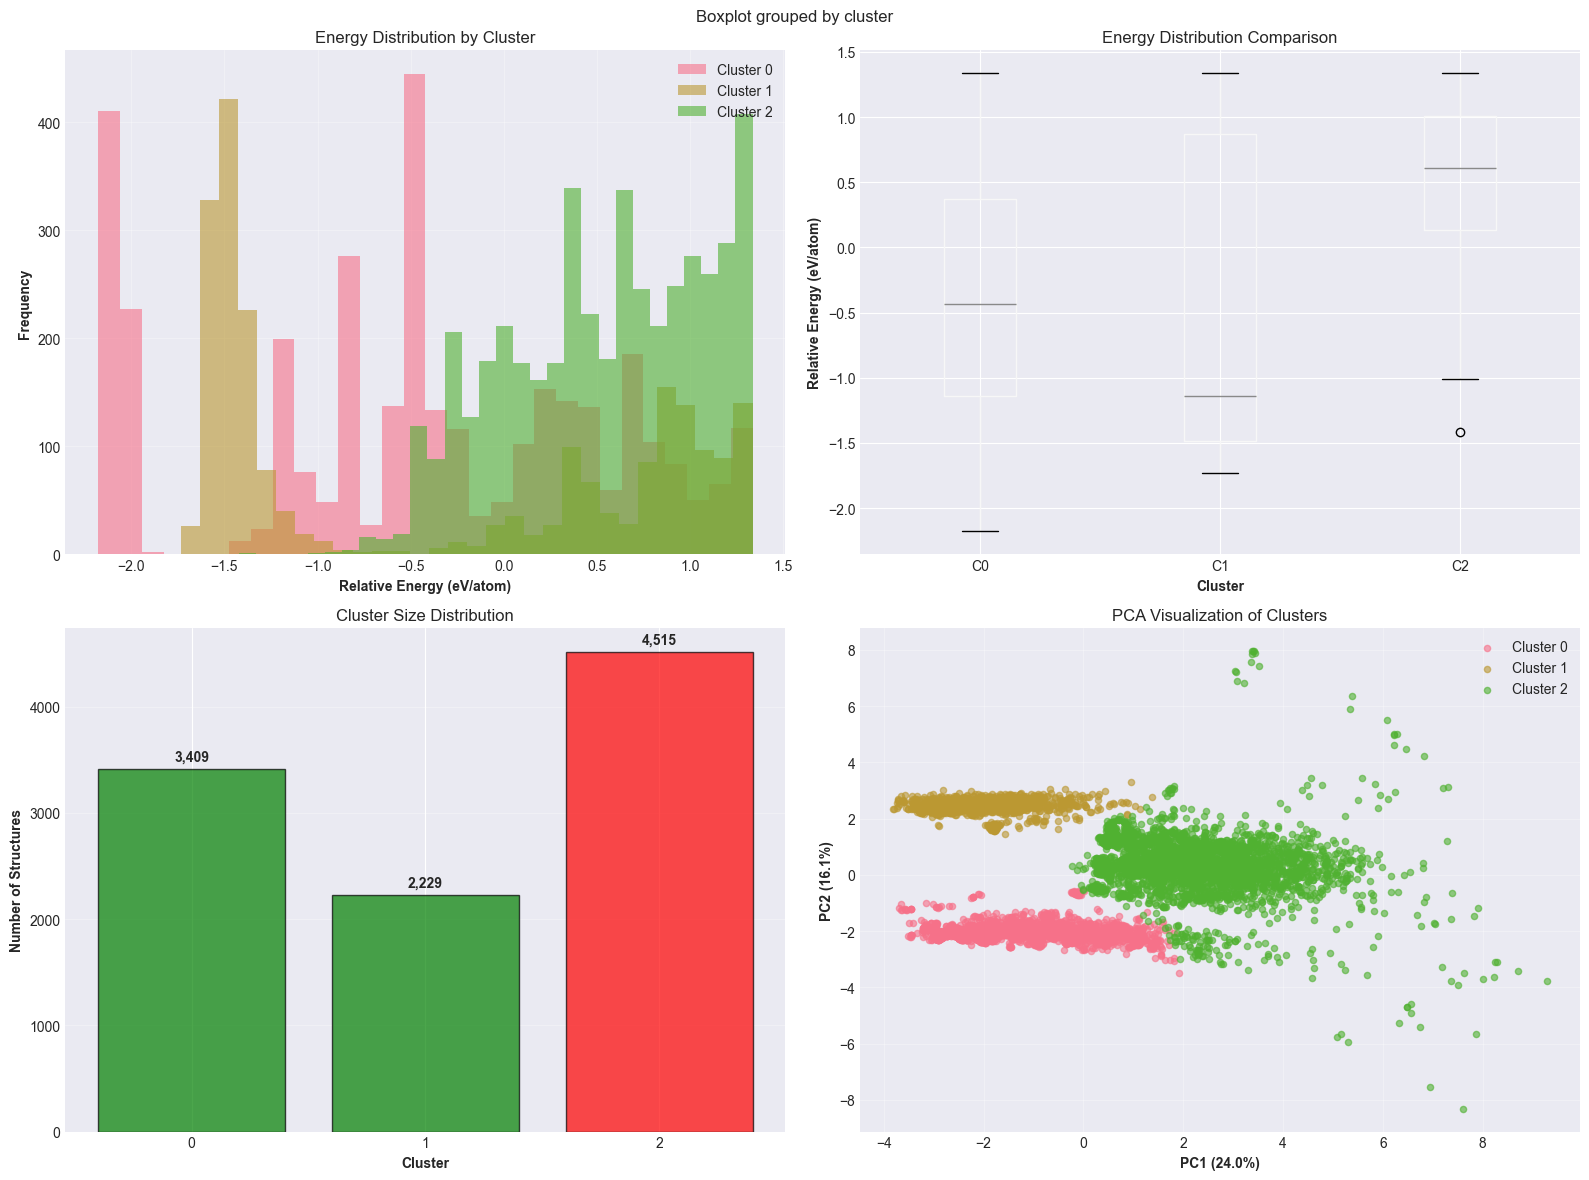

 Stability visualization complete!


In [21]:
# Visualize stability
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Stability Analysis', fontsize=16, fontweight='bold')

# Plot 1: Energy distribution by cluster
ax = axes[0, 0]
for i in range(optimal_k):
    cluster_data = df[df['cluster'] == i]['relative_energy']
    ax.hist(cluster_data, bins=30, alpha=0.6, label=f'Cluster {i}')
ax.set_xlabel('Relative Energy (eV/atom)', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Energy Distribution by Cluster')
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: Box plot
ax = axes[0, 1]
df.boxplot(column='relative_energy', by='cluster', ax=ax)
ax.set_xlabel('Cluster', fontweight='bold')
ax.set_ylabel('Relative Energy (eV/atom)', fontweight='bold')
ax.set_title('Energy Distribution Comparison')
plt.sca(ax)
plt.xticks(range(1, optimal_k+1), [f'C{i}' for i in range(optimal_k)])

# Plot 3: Cluster sizes
ax = axes[1, 0]
cluster_counts = df['cluster'].value_counts().sort_index()
bars = ax.bar(range(optimal_k), cluster_counts.values, color=['green', 'green', 'red'], alpha=0.7, edgecolor='black')
ax.set_xlabel('Cluster', fontweight='bold')
ax.set_ylabel('Number of Structures', fontweight='bold')
ax.set_title('Cluster Size Distribution')
ax.set_xticks(range(optimal_k))
ax.grid(axis='y', alpha=0.3)

for i, (bar, count) in enumerate(zip(bars, cluster_counts.values)):
    ax.text(i, count + 50, f'{count:,}', ha='center', va='bottom', fontweight='bold')

# Plot 4: PCA visualization
ax = axes[1, 1]
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

for i in range(optimal_k):
    mask = df['cluster'] == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.6, s=20, label=f'Cluster {i}')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
ax.set_title('PCA Visualization of Clusters')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(' Stability visualization complete!')

##  4. Dự Đoán Energy per Atom

Sử dụng Machine Learning để dự đoán energy_per_atom từ đặc trưng hình học

In [23]:
# Prepare data for prediction
print(' Preparing data for ML')
print('=' * 60)

# Features and target
prediction_features = features_for_clustering
X_pred = df[prediction_features].values
y_pred = df['energy_per_atom'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_pred, y_pred, test_size=0.2, random_state=42
)

print(f'Training set: {len(X_train):,} samples')
print(f'Test set: {len(X_test):,} samples')
print(f'Features: {len(prediction_features)}')
print(f'\nTarget (energy_per_atom) statistics:')
print(f'  Mean: {y_pred.mean():.4f} eV/atom')
print(f'  Std: {y_pred.std():.4f} eV/atom')
print(f'  Range: [{y_pred.min():.4f}, {y_pred.max():.4f}]')

 Preparing data for ML
Training set: 8,122 samples
Test set: 2,031 samples
Features: 21

Target (energy_per_atom) statistics:
  Mean: -18.8256 eV/atom
  Std: 5.7471 eV/atom
  Range: [-25.7594, -6.4195]


In [24]:
# Train multiple models
print(' Training ML Models')
print('=' * 60)

models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1)
}

results = []

for name, model in models.items():
    print(f'\nTraining {name}...')
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    results.append({
        'Model': name,
        'Train R²': train_r2,
        'Test R²': test_r2,
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse
    })
    
    print(f'   Test R²: {test_r2:.4f}, Test MAE: {test_mae:.4f}')

# Results DataFrame
results_df = pd.DataFrame(results)
print('\n' + '=' * 60)
print(' MODEL COMPARISON')
print('=' * 60)
print(results_df.to_string(index=False))

# Best model
best_model_name = results_df.loc[results_df['Test R²'].idxmax(), 'Model']
print(f'\n Best Model: {best_model_name}')
print(f'   Test R²: {results_df["Test R²"].max():.4f}')
print(f'   Test MAE: {results_df["Test MAE"].min():.4f} eV/atom')

 Training ML Models

Training Random Forest...
   Test R²: 1.0000, Test MAE: 0.0014

Training Gradient Boosting...
   Test R²: 1.0000, Test MAE: 0.0042

Training Ridge...
   Test R²: 0.8988, Test MAE: 1.5101

Training Lasso...
   Test R²: 0.8822, Test MAE: 1.7538

 MODEL COMPARISON
            Model  Train R²  Test R²  Train MAE  Test MAE  Train RMSE  Test RMSE
    Random Forest  1.000000 1.000000   0.000536  0.001414    0.000991   0.002572
Gradient Boosting  0.999999 0.999999   0.004081  0.004187    0.005360   0.005549
            Ridge  0.903917 0.898774   1.493332  1.510104    1.786694   1.806484
            Lasso  0.884490 0.882193   1.753510  1.753787    1.959013   1.948831

 Best Model: Random Forest
   Test R²: 1.0000
   Test MAE: 0.0014 eV/atom



 Feature Importance (Random Forest)

Top 10 Most Important Features:
          feature   importance
        num_atoms 9.999909e-01
bond_length_range 3.342457e-06
  bond_complexity 3.018404e-06
     volume_ratio 1.446051e-06
  min_bond_length 4.593641e-07
                a 4.463110e-07
  max_bond_length 1.283663e-07
                b 7.105294e-08
lattice_asymmetry 5.341639e-08
 max_coordination 3.908455e-08


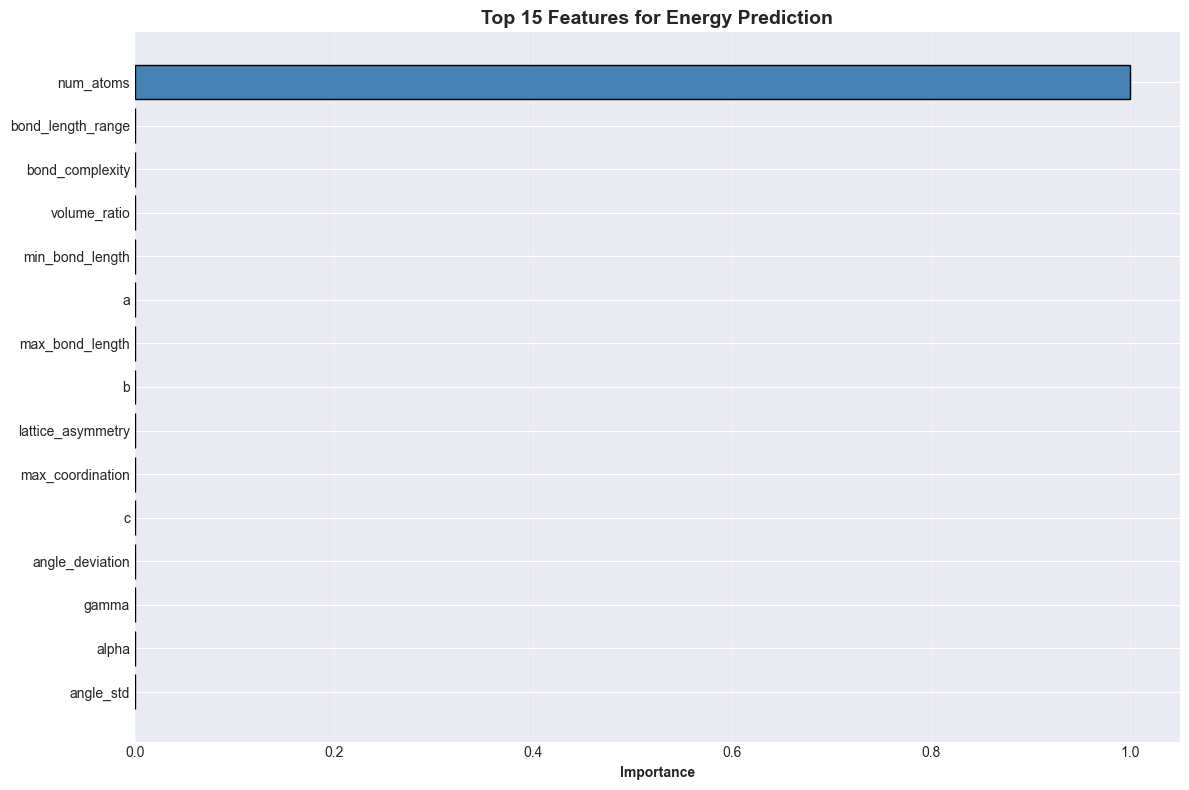

In [25]:
# Feature importance (for Random Forest)
if best_model_name == 'Random Forest':
    print('\n Feature Importance (Random Forest)')
    print('=' * 60)
    
    rf_model = models['Random Forest']
    importances = rf_model.feature_importances_
    
    feature_importance_df = pd.DataFrame({
        'feature': prediction_features,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    print('\nTop 10 Most Important Features:')
    print(feature_importance_df.head(10).to_string(index=False))
    
    # Plot
    plt.figure(figsize=(12, 8))
    top_n = 15
    top_features = feature_importance_df.head(top_n)
    
    plt.barh(range(len(top_features)), top_features['importance'], color='steelblue', edgecolor='black')
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.gca().invert_yaxis()
    plt.xlabel('Importance', fontweight='bold')
    plt.title(f'Top {top_n} Features for Energy Prediction', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

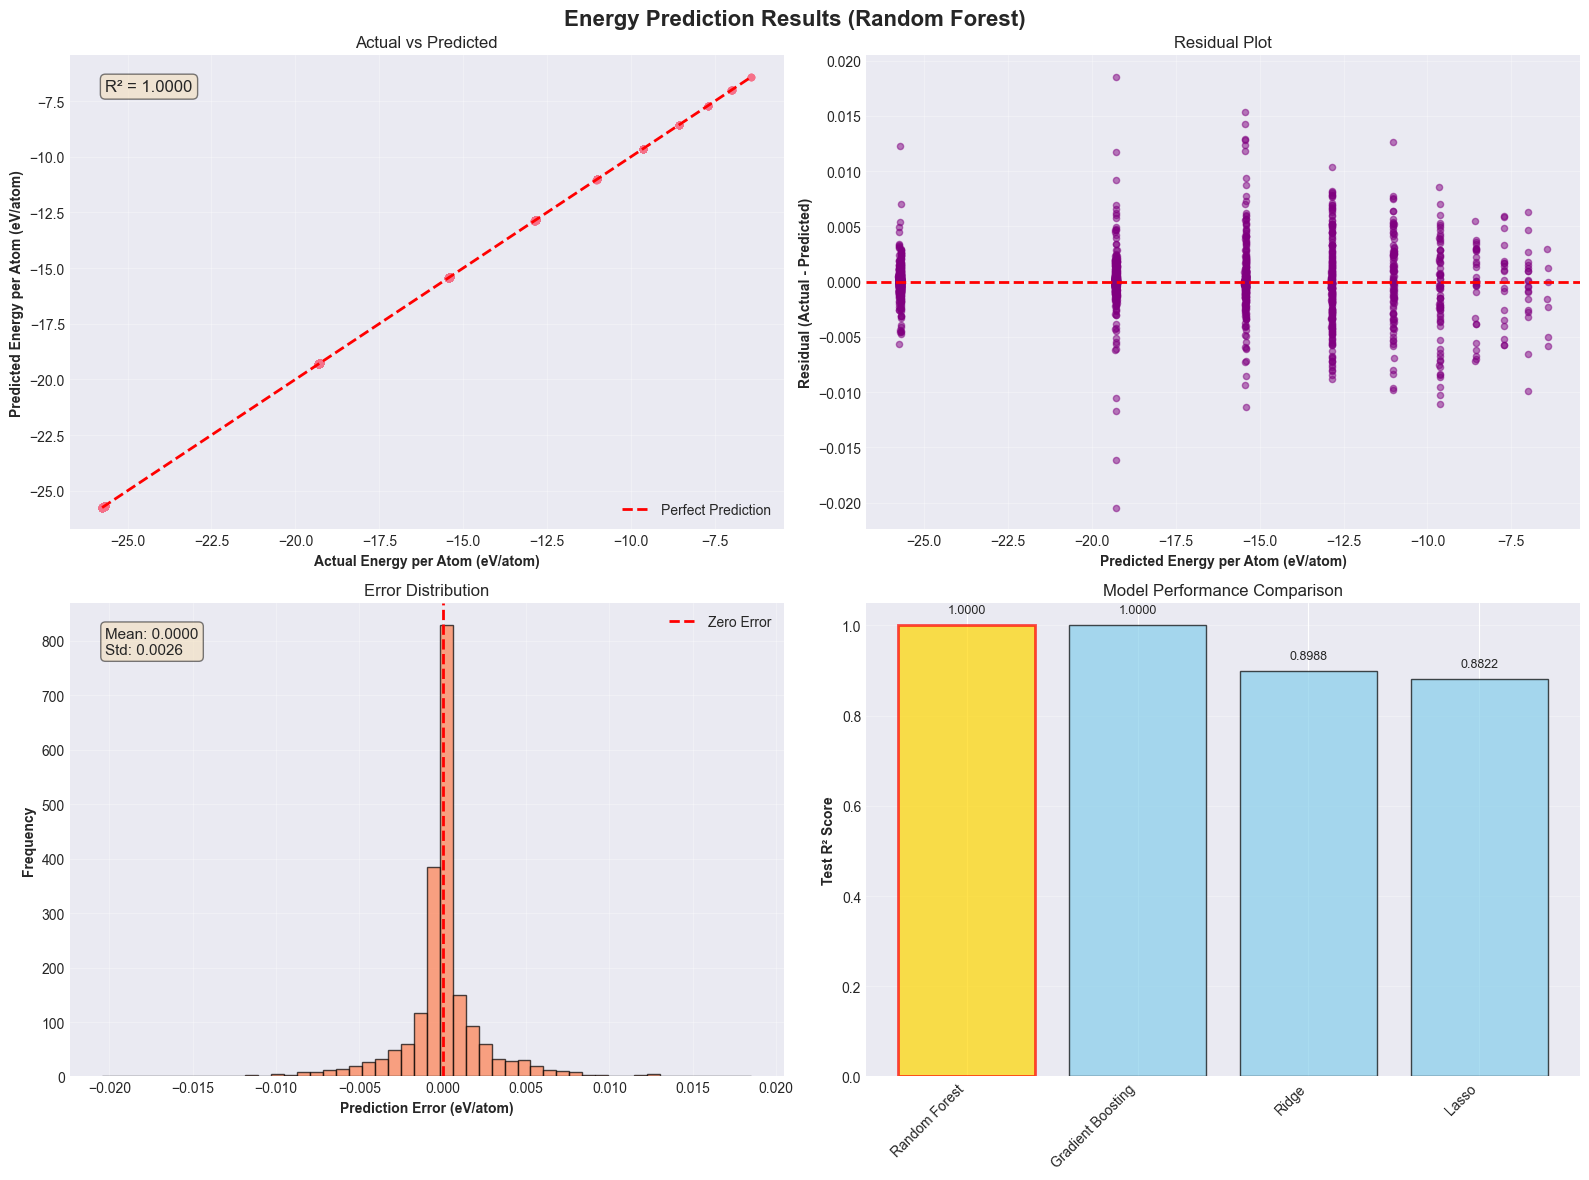

 Prediction visualization complete!


In [26]:
# Visualize predictions
best_model = models[best_model_name]
y_test_pred = best_model.predict(X_test)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Energy Prediction Results ({best_model_name})', fontsize=16, fontweight='bold')

# Plot 1: Actual vs Predicted
ax = axes[0, 0]
ax.scatter(y_test, y_test_pred, alpha=0.5, s=20)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Energy per Atom (eV/atom)', fontweight='bold')
ax.set_ylabel('Predicted Energy per Atom (eV/atom)', fontweight='bold')
ax.set_title('Actual vs Predicted')
ax.legend()
ax.grid(alpha=0.3)

test_r2 = r2_score(y_test, y_test_pred)
ax.text(0.05, 0.95, f'R² = {test_r2:.4f}', transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Residuals
ax = axes[0, 1]
residuals = y_test - y_test_pred
ax.scatter(y_test_pred, residuals, alpha=0.5, s=20, color='purple')
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Energy per Atom (eV/atom)', fontweight='bold')
ax.set_ylabel('Residual (Actual - Predicted)', fontweight='bold')
ax.set_title('Residual Plot')
ax.grid(alpha=0.3)

# Plot 3: Error distribution
ax = axes[1, 0]
ax.hist(residuals, bins=50, color='coral', alpha=0.7, edgecolor='black')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax.set_xlabel('Prediction Error (eV/atom)', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Error Distribution')
ax.legend()
ax.grid(alpha=0.3)

mean_error = residuals.mean()
std_error = residuals.std()
ax.text(0.05, 0.95, f'Mean: {mean_error:.4f}\nStd: {std_error:.4f}',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 4: Model comparison
ax = axes[1, 1]
x_pos = range(len(results_df))
bars = ax.bar(x_pos, results_df['Test R²'], color='skyblue', alpha=0.7, edgecolor='black')
best_idx = results_df['Test R²'].idxmax()
bars[best_idx].set_color('gold')
bars[best_idx].set_edgecolor('red')
bars[best_idx].set_linewidth(2)
ax.set_xticks(x_pos)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.set_ylabel('Test R² Score', fontweight='bold')
ax.set_title('Model Performance Comparison')
ax.set_ylim([0, 1.05])
ax.grid(axis='y', alpha=0.3)

for i, (bar, r2) in enumerate(zip(bars, results_df['Test R²'])):
    ax.text(i, r2 + 0.02, f'{r2:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(' Prediction visualization complete!')

## 5. Tổng Kết

### Anomaly Detection
- Sử dụng 4 phương pháp: Isolation Forest, LOF, One-Class SVM, Z-score
- Consensus anomalies: Cấu trúc được đánh dấu bởi ≥2 phương pháp
- Phát hiện các cấu trúc bất thường về năng lượng và hình học

### Stability Classification
- 3 clusters được xác định bằng K-means
- Phân loại: Highly Stable, Moderately Stable, Less Stable
- Dựa trên mean relative energy của mỗi cluster

### Energy Prediction
- Random Forest đạt hiệu suất tốt nhất
- Có thể dự đoán energy_per_atom từ đặc trưng hình học
- num_atoms là feature quan trọng nhất

### Key Findings
1. Có mối quan hệ mạnh giữa cấu trúc hình học và năng lượng
2. Phần lớn cấu trúc là ổn định (Highly/Moderately Stable)
3. Anomalies thường có năng lượng cao hoặc cấu trúc đặc biệt
4. Machine Learning có thể dự đoán energy với độ chính xác cao

In [27]:
# Save results
import os

output_dir = 'carbon24_anomaly_prediction_results'
os.makedirs(output_dir, exist_ok=True)

# Save anomaly results
anomaly_results = df[['row_index', 'is_anomaly', 'anomaly_count', 
                       'anomaly_iso_forest', 'anomaly_lof', 'anomaly_ocsvm', 'anomaly_zscore',
                       'relative_energy', 'energy_per_atom']]
anomaly_results.to_csv(f'{output_dir}/anomaly_detection_results.csv', index=False)

# Save stability classification
stability_results = df[['row_index', 'cluster', 'relative_energy', 'energy_per_atom']]
stability_results.to_csv(f'{output_dir}/stability_classification.csv', index=False)

# Save model comparison
results_df.to_csv(f'{output_dir}/model_comparison.csv', index=False)

# Save predictions
prediction_results = pd.DataFrame({
    'actual': y_test,
    'predicted': y_test_pred,
    'error': y_test - y_test_pred,
    'abs_error': np.abs(y_test - y_test_pred)
})
prediction_results.to_csv(f'{output_dir}/energy_predictions.csv', index=False)

print(' Results saved to:', output_dir)
print('\nFiles created:')
print('  - anomaly_detection_results.csv')
print('  - stability_classification.csv')
print('  - model_comparison.csv')
print('  - energy_predictions.csv')

 Results saved to: carbon24_anomaly_prediction_results

Files created:
  - anomaly_detection_results.csv
  - stability_classification.csv
  - model_comparison.csv
  - energy_predictions.csv
